In [6]:
# Celda de prueba
import sys
print(f"¿Estoy en el entorno correcto?: {'.venv' in sys.executable}")
print(sys.executable)

¿Estoy en el entorno correcto?: True
c:\Users\marqu\OneDrive\INAOE_PROPE\INAOE_DSA\INAOE_practice\.venv\Scripts\python.exe


| Estructura        | Nivel de dificultad | Por qué es importante para ti |
|------------------|-------------------|--------------------------------|
| Arrays & Strings | ⭐ (Fácil)        | Son la base de todo. Un bloque sólido de memoria. |
| Stacks & Queues  | ⭐⭐ (Fácil-Medio) | Fundamentales para entender cómo se ejecutan los programas y los ataques de Buffer Overflow. |
| Linked Lists     | ⭐⭐⭐ (Medio)      | Aquí aprendes sobre "apuntadores" (direcciones de memoria). Es el primer paso real hacia la computación. |
| Hash Tables      | ⭐⭐⭐⭐ (Medio-Alto)| Vital para Ciberseguridad. Es la base de las funciones Hash (SHA-256) que verás en el libro de Bitcoin. |
| Trees & Graphs   | ⭐⭐⭐⭐⭐ (Alto)     | Lo más difícil de programar, pero lo más parecido a tu formación matemática (Nodos y Aristas). |

# Concepto: Stack (Pila)

**Regla:** LIFO (*Last-In, First-Out*) / El último en entrar es el primero en salir.

**Complejidad Temporal:** 
* **Push** (Insertar): $O(1)$
* **Pop** (Eliminar): $O(1)$
* **Peek** (Mirar el tope): $O(1)$

---
### Representación Visual
Imagine una pila de libros: solo puedes interactuar con el que está arriba.

In [4]:
# Implementación simple de una Pila
stack = []

# Push (Añadir)
stack.append("Dato A")
stack.append("Dato B")

# Pop (Sacar)
top = stack.pop() 
print(f"Salió: {top}") # Debería ser 'Dato B'
print(f"Queda en la pila: {stack}")

Salió: Dato B
Queda en la pila: ['Dato A']


Pila es solo una lista donde solo puedes tocar el último elemento.

Imagina esto: Estás revisando los paquetes de red que llegan a tu servidor. Los vas apilando. Si llega un paquete malicioso que dice "ejecuta esto ahora", y está hasta arriba de la pila, la computadora lo va a sacar y ejecutar primero. ¡Eso es un concepto de seguridad basado en una estructura de datos!

Relación con Ciber: El Call Stack es donde el CPU guarda las direcciones de retorno de las funciones. 

Si un atacante inunda esta pila con datos (Buffer Overflow), puede sobreescribir la dirección de retorno y ejecutar código malicioso.

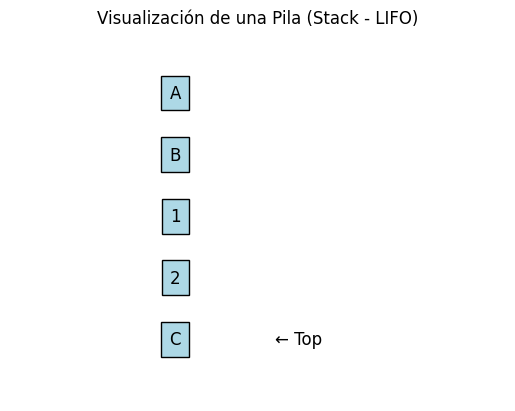

In [11]:
%matplotlib inline
import matplotlib.pyplot as plt

stack = ["A", "B", 1, 2, "C"]

fig, ax = plt.subplots()

# Dibujar la pila
for i, val in enumerate(stack):
    y = i
    ax.text(
        0.5, y, str(val),
        ha='center', va='center',
        fontsize=12,
        bbox=dict(facecolor='lightblue', edgecolor='black', boxstyle="square,pad=0.5")
    )

# Marcar el TOP
top_index = len(stack) - 1
ax.text(0.8, top_index, "← Top", va='center', fontsize=12)

# Ajustes visuales
ax.set_xlim(0, 1.5)
ax.set_ylim(-1, len(stack))
ax.invert_yaxis()  # 🔥 esto hace que el top esté arriba
ax.axis('off')

plt.title('Visualización de una Pila (Stack - LIFO)')
plt.show()

🧩 IDEA CENTRAL (muy simple)

👉 C++ genera datos
👉 Python los lee y los dibuja

Se comunican usando un archivo:
stack.txt

stack<int> s; → crea una pila real en C++
push() → mete elementos
ofstream file("stack.txt"); → abre archivo para escribir
file << s.top() → guarda el valor actual
s.pop() → lo elimina (simula stack real)


open("stack.txt") → abre archivo creado por C++
f.read().split() → convierte "3 2 1" → ["3","2","1"]
map(int, ...) → convierte a números
stack = [...] → ya tienes la pila en Python
matplotlib → la dibuja

👉 Python permite mezclar tipos

En C++:

👉 NO puedes hacer eso directamente
👉 necesitas:

string (más simple)
o estructuras más avanzadas (variant, union, etc.)


C++                Archivo            Python
----               --------           -------
push/pop   →       stack.txt   →      visualización
(memoria real)     (puente)           (intuición)

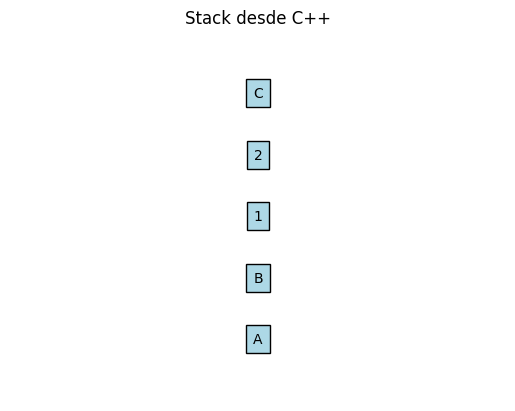

In [18]:
import matplotlib.pyplot as plt

# Leer archivo
with open("./cpp_practice/stack.txt") as f:
    stack = list(map(str, f.read().split()))

# Dibujar
fig, ax = plt.subplots()

spacing = 0.5 # Espacio entre elementos

for i, val in enumerate(stack):
    y = i * spacing
    ax.text(
        0.5, y, str(val),
        ha='center', va='center',
        bbox=dict(facecolor='lightblue', edgecolor='black', boxstyle="square,pad=0.5")
    )

ax.set_ylim(-spacing, len(stack) * spacing)
ax.invert_yaxis()
ax.axis('off')

plt.title("Stack desde C++")
plt.show()

# 01. Análisis de Complejidad (Big O)

La notación asintótica nos permite medir la eficiencia de un algoritmo independientemente del hardware.

### Tabla de Complejidades Comunes

| Nombre (ES) | Term (EN) | Notación | Ejemplo |
| :--- | :--- | :--- | :--- |
| Constante | Constant | $O(1)$ | Acceso a un índice de Array |
| Logarítmica | Logarithmic | $O(\log n)$ | Búsqueda Binaria |
| Lineal | Linear | $O(n)$ | Búsqueda simple / Recorrer lista |
| Cuadrática | Quadratic | $O(n^2)$ | Bubble Sort / Bucles anidados |

---

### Comparación Matemática
Cuando $n$ crece, la diferencia es radical:
$$\log n \ll n \ll n \log n \ll n^2$$

> **Nota para el INAOE:** En Ciberseguridad, buscamos que los algoritmos de cifrado sean costosos para el atacante ($O(2^n)$) pero eficientes para el usuario ($O(1)$ o $O(n)$).

In [5]:
import time

def medidor_lineal(n):
    lista = list(range(n))
    inicio = time.time()
    
    # Operación O(n): Recorrer la lista
    for x in lista:
        pass 
        
    fin = time.time()
    print(f"Para n={n}, tardó: {fin - inicio:.6f} segundos")

medidor_lineal(1000000) # Prueba con un millón

Para n=1000000, tardó: 0.006684 segundos


# 02. Pilas y Colas (Stacks & Queues)

Estas son estructuras de datos lineales con reglas de acceso restringidas. Son fundamentales para entender el manejo de memoria en **C** y **C++**.

### Comparativa: LIFO vs FIFO

| Estructura | Regla | Significado | Operación Principal |
| :--- | :--- | :--- | :--- |
| **Stack (Pila)** | **LIFO** | *Last-In, First-Out* | `push` / `pop` |
| **Queue (Cola)** | **FIFO** | *First-In, First-Out* | `enqueue` / `dequeue` |



### Complejidad Temporal
Para ambas estructuras, las operaciones de inserción y extracción son extremadamente eficientes:
$$O(1)$$

> **Dato para Ciberseguridad:** El **Stack** es donde se almacenan las variables locales y direcciones de retorno de funciones. Un "Stack Overflow" no es solo un sitio web, es un error de memoria real que ocurre cuando la pila crece más allá de sus límites.

In [6]:
# Creando una Pila (Stack) usando una lista
pila_estudio = []

# Push: Agregamos elementos al final
pila_estudio.append("Matemáticas")
pila_estudio.append("Algoritmos")
pila_estudio.append("Ciberseguridad")

print(f"Estado de la pila: {pila_estudio}")

# Pop: Sacamos el último en entrar
ultimo = pila_estudio.pop()
print(f"Elemento extraído (LIFO): {ultimo}")
print(f"Pila restante: {pila_estudio}")

Estado de la pila: ['Matemáticas', 'Algoritmos', 'Ciberseguridad']
Elemento extraído (LIFO): Ciberseguridad
Pila restante: ['Matemáticas', 'Algoritmos']


# 03. Listas Ligadas (Linked Lists)

A diferencia de los arreglos, las listas ligadas **no ocupan bloques contiguos de memoria**. Cada elemento es un objeto independiente llamado **Nodo**.

### Anatomía de un Nodo
Un nodo tiene dos partes fundamentales:
1. **Data:** El valor almacenado.
2. **Next (Puntero):** La dirección de memoria del siguiente nodo.

### Complejidad Temporal ($O$)
* **Acceso / Búsqueda:** $O(n)$ (Debes recorrerla desde el inicio o `Head`).
* **Inserción al inicio:** $O(1)$ (Solo cambias un puntero).
* **Eliminación al inicio:** $O(1)$.

---
### Comparativa Matemática: Array vs Linked List
| Característica | Array | Linked List |
| :--- | :--- | :--- |
| Memoria | Contigua (Estática) | Dispersa (Dinámica) |
| Acceso $O(1)$ | Sí (por índice) | No (por recorrido) |
| Inserción | Costosa $O(n)$ | Barata $O(1)$ |

> **Nota para Ciberseguridad:** Entender listas ligadas es entender cómo se maneja el **Heap** (memoria dinámica). Muchos ataques de "Memory Corruption" ocurren al manipular mal estos punteros.

In [7]:
class Nodo:
    def __init__(self, dato):
        self.dato = dato
        self.siguiente = None # Puntero al siguiente nodo

# Creando los nodos de forma manual para entender la lógica
cabeza = Nodo("INAOE")
segundo = Nodo("Ciberseguridad")
tercero = Nodo("2026")

# "Ligando" los nodos (Creando las aristas del grafo)
cabeza.siguiente = segundo
segundo.siguiente = tercero

# Recorriendo la lista (Traversal)
actual = cabeza
while actual:
    print(f"Nodo: {actual.dato} -> ", end="")
    actual = actual.siguiente
print("None")

Nodo: INAOE -> Nodo: Ciberseguridad -> Nodo: 2026 -> None


In [8]:
def insertar_inicio(self, nuevo_dato):
    nuevo_nodo = Nodo(nuevo_dato)
    nuevo_nodo.siguiente = self.cabeza # El nuevo apunta al que era el primero
    self.cabeza = nuevo_nodo           # El nuevo ahora es la nueva "Cabeza"